# REGRESSÃO LINEAR SIMPLES       

A Regressão Linear Simples é uma ferramenta estatística para
  entender a relação entre duas coisas. Imagine que você quer prever
  uma delas (o "resultado") baseando-se em apenas uma outra informação
  (a "causa").

  Aqui está a explicação em 3 pontos simples:

   1. O Objetivo: Descobrir como uma variável (ex: Distância
      percorrida) influencia outra (ex: Tempo de entrega).
   2. A "Reta": O computador desenha uma linha reta que tenta passar o
      mais perto possível de todos os pontos de dados que você já tem.
   3. A Previsão: Com essa reta pronta, se você me der um valor novo
      (ex: "Vou percorrer 20km"), a regressão me diz exatamente qual é
      o resultado esperado (ex: "Vai levar 45 minutos").

  A fórmula básica que você verá no notebook é:
  Y = α + β X
   * Y: O que você quer descobrir (Tempo).
   * X: A informação que você já tem (Distância).
   * α e β: São os números que o modelo aprende para criar a reta
     perfeita.

  Em resumo: é transformar dados em uma linha reta para prever o
  futuro com base no passado.

#### EXEMPLO 1 - Quanto tempo é gasto para percorrer a distancia 

1 - Importação dos pacotes

In [1]:
import pandas as pd # manipulação de dados em formato de dataframe
import numpy as np # operações matemáticas
import seaborn as sns # visualização gráfica
import matplotlib.pyplot as plt # visualização gráfica
import plotly.graph_objects as go # gráficos 3D
from scipy.stats import pearsonr # correlações de Pearson
import statsmodels.api as sm # estimação de modelos
from statsmodels.iolib.summary2 import summary_col # comparação entre modelos
from sklearn.preprocessing import LabelEncoder # transformação de dados
import pingouin as pg # outro modo para obtenção de matrizes de correlações
from statstests.process import stepwise # procedimento Stepwise
from statstests.tests import shapiro_francia # teste de Shapiro-Francia
from scipy.stats import boxcox # transformação de Box-Cox
from scipy.stats import norm # para plotagem da curva normal
from scipy import stats # utilizado na definição da função 'breusch_pagan_test'


import warnings
warnings.filterwarnings('ignore')

2 - Carregando Dados

In [2]:
# CARREGAMENTO DA BASE DE DADOS
df_tempodist = pd.read_csv('tempodist.csv', delimiter=',')
df_tempodist

,tempo,distancia
0,15,8
1,20,6
2,20,15
3,40,20
4,50,25
5,25,11
6,10,5
7,55,32
8,35,28
9,30,20


2.1 - Caracteristicas das variaveis dotaset

In [3]:
# Características das variáveis do dataset
df_tempodist.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tempo      10 non-null     int64
 1   distancia  10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


2.2 - Estatísticas univariadas

In [4]:
# Estatísticas univariadas
df_tempodist.describe()

,tempo,distancia
count,10.00000,10.000000
mean,30.00000,17.000000
std,14.90712,9.510228
min,10.00000,5.000000
25%,20.00000,8.750000
50%,27.50000,17.500000
75%,38.75000,23.750000
max,55.00000,32.000000


3 - Gráfico de dispersão com o ajuste linear (fitted values de um modelo de regressão) que se adequa às observações: função 'regplot' do pacote 'seaborn'

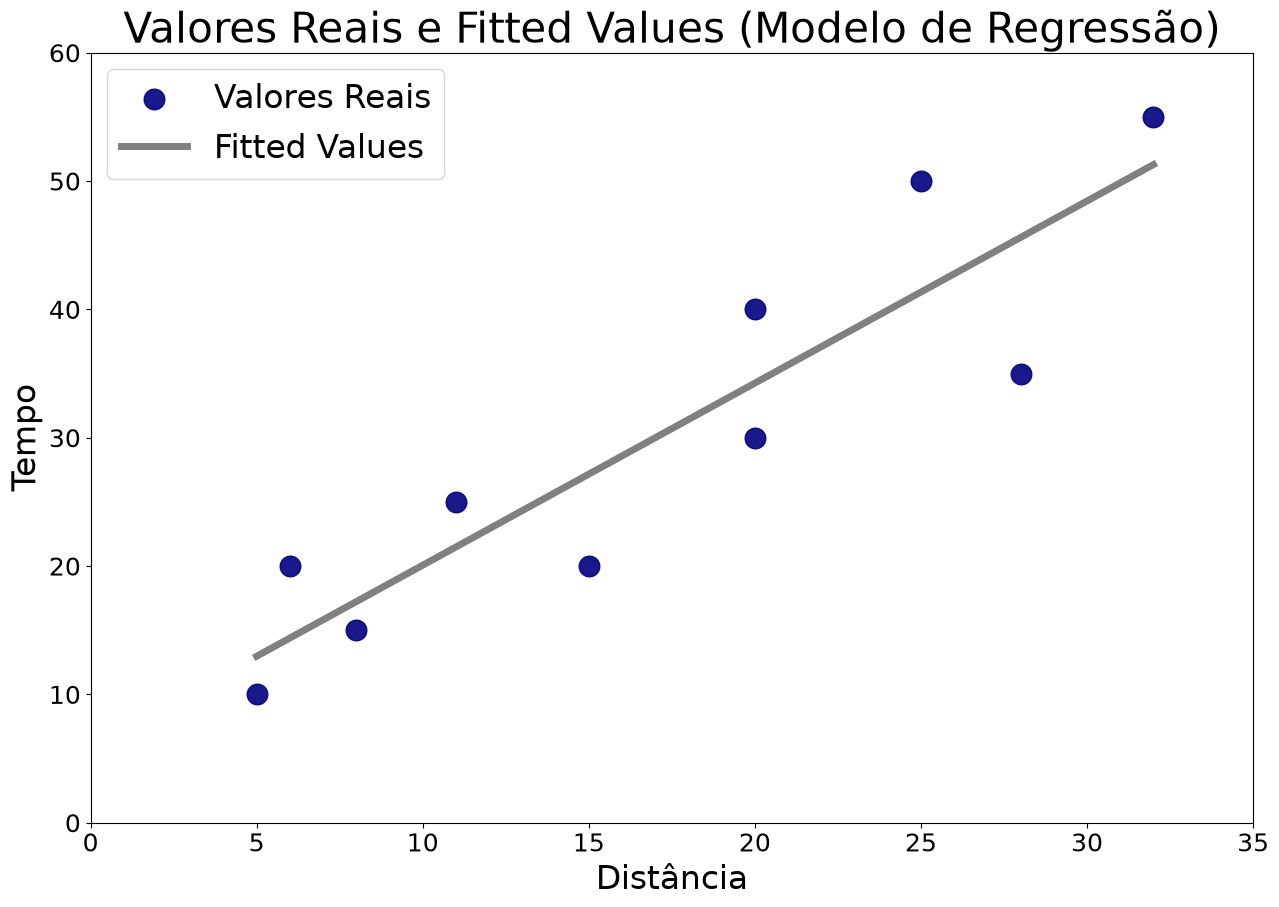

In [5]:
# 1. Cria o espaço do gráfico: define o tamanho da imagem (15 de largura por 10 de altura)
plt.figure(figsize=(15,10))

    # 2. O CORAÇÃO DO GRÁFICO (sns.regplot):
    # - data: usa o seu conjunto de dados (df_tempodist)
    # - x e y: define que a 'distancia' causa o 'tempo'
    # - marker='o': desenha os pontos como círculos
    # - ci=False: remove uma sombra de erro que fica em volta da linha (intervalo de confiança)
    # - scatter_kws: personaliza os PONTOS (cor azul marinho, 90% de opacidade, tamanho 220)
    # - line_kws: personaliza a LINHA (cor cinza, espessura 5) -> AQUI É GERADA A REGRESSÃO
sns.regplot(data=df_tempodist, x='distancia', y='tempo', marker='o', ci=False,
            scatter_kws={"color":'navy', 'alpha':0.9, 's':220},
line_kws={"color":'grey', 'linewidth': 5})
plt.title('Valores Reais e Fitted Values (Modelo de Regressão)', fontsize=30)
plt.xlabel('Distância', fontsize=24)
plt.ylabel('Tempo', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(0, 35)
plt.ylim(0, 60)
plt.legend(['Valores Reais', 'Fitted Values'], fontsize=24, loc='upper left')
plt.show()


4 - Estimação do modelo de regressão linear simples

In [6]:
# Estimação do modelo
modelo = sm.OLS.from_formula('tempo ~ distancia', df_tempodist).fit()

4.1 - Observação dos parâmetros resultantes da estimação

In [7]:
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  tempo   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     36.30
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           0.000314
Time:                        22:12:59   Log-Likelihood:                -32.123
No. Observations:                  10   AIC:                             68.25
Df Residuals:                       8   BIC:                             68.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.8784      4.532      1.297      0.2

# Análise da Regressão Linear (OLS)

## Resumo do Modelo

O objetivo deste modelo é analisar a relação entre a variável **distância** (variável explicativa) e a variável **tempo** (variável resposta).

### Equação da Regressão

[
Tempo = 5.8784 + 1.4189 \times Distância
]

Onde:

* **Intercepto:** 5.8784
* **Coeficiente da Distância:** 1.4189

### Interpretação da Equação

O modelo indica que:

* Quando a distância é igual a zero, o tempo estimado é aproximadamente **5,88 unidades**.
* Para cada unidade adicional de distância, o tempo aumenta em média **1,42 unidades**.

---

# Qualidade do Ajuste

## Coeficiente de Determinação (R²)

**R² = 0,819**

Isso significa que o modelo consegue explicar aproximadamente **81,9% da variação observada no tempo**.

### Interpretação

| Faixa de R²   | Qualidade |
| ------------- | --------- |
| 0,00 – 0,30   | Fraca     |
| 0,30 – 0,60   | Moderada  |
| 0,60 – 0,80   | Boa       |
| Acima de 0,80 | Muito Boa |

O valor encontrado indica que o modelo possui **excelente capacidade explicativa**.

---

# Significância do Modelo

## Teste F

| Métrica           | Valor    |
| ----------------- | -------- |
| F-statistic       | 36,30    |
| Prob(F-statistic) | 0,000314 |

### Hipóteses

**H₀:** O modelo não possui capacidade explicativa.

**H₁:** O modelo possui capacidade explicativa.

### Resultado

Como:

[
p = 0.000314 < 0.05
]

rejeitamos H₀.

### Conclusão

O modelo é estatisticamente significativo ao nível de confiança de 95%.

---

# Análise dos Coeficientes

## Intercepto

| Coeficiente | Erro Padrão | t     | p-valor |
| ----------- | ----------- | ----- | ------- |
| 5.8784      | 4.532       | 1.297 | 0.231   |

### Interpretação

O intercepto não apresentou significância estatística, pois:

[
p = 0.231 > 0.05
]

Isso indica que não há evidências suficientes para afirmar que o intercepto seja diferente de zero.

---

## Distância

| Coeficiente | Erro Padrão | t     | p-valor |
| ----------- | ----------- | ----- | ------- |
| 1.4189      | 0.235       | 6.025 | 0.000   |

### Interpretação

A variável distância apresentou alta significância estatística.

Como:

[
p < 0.001
]

podemos afirmar que existe uma forte evidência de que a distância influencia diretamente o tempo.

---

# Intervalo de Confiança

Para o coeficiente da variável distância:

| Limite Inferior | Limite Superior |
| --------------- | --------------- |
| 0.876           | 1.962           |

### Interpretação

Com 95% de confiança, o impacto real da distância sobre o tempo encontra-se entre:

* 0,876 unidades
* 1,962 unidades

Como o intervalo não contém o valor zero, a variável é considerada estatisticamente significativa.

---

# Diagnóstico dos Resíduos

## Autocorrelação

### Durbin-Watson

Valor obtido:

[
DW = 2.099
]

### Interpretação

Valores próximos de 2 indicam ausência de autocorrelação.

Portanto:

**Não foram encontrados indícios de autocorrelação dos resíduos.**

---

## Teste de Normalidade

### Omnibus

| Estatística   | Valor |
| ------------- | ----- |
| Prob(Omnibus) | 0.602 |

### Jarque-Bera

| Estatística | Valor |
| ----------- | ----- |
| Prob(JB)    | 0.707 |

### Interpretação

Como ambos os p-valores são maiores que 0,05:

* Não rejeitamos a hipótese de normalidade.
* Os resíduos podem ser considerados aproximadamente normais.

---

# Exemplo de Previsão

Supondo uma distância de 10 unidades:

[
Tempo = 5.8784 + (1.4189 \times 10)
]

[
Tempo = 20.0674
]

### Resultado

Para uma distância de 10 unidades, o modelo prevê um tempo aproximado de:

**20,07 unidades**

---

# Conclusão Executiva

A análise demonstra que:

✅ O modelo possui excelente capacidade explicativa (R² = 81,9%).

✅ O modelo é estatisticamente significativo (p < 0,001).

✅ A variável distância exerce influência positiva e significativa sobre o tempo.

✅ Os resíduos apresentam comportamento adequado para aplicação da regressão linear.

✅ Não foram detectados problemas relevantes de autocorrelação.

### Conclusão Final

Existe uma relação linear forte e positiva entre distância e tempo. O modelo pode ser utilizado para realizar previsões com boa confiabilidade dentro da faixa observada dos dados.


#### Salvando fitted values (variável yhat) e residuals (variável erro) no dataset

4.2 - Estimando apartir da formula
t = intercept + (distancia X distancia)

In [8]:
tempo = 5.8784 + 1.4189 * 22
print(tempo)

37.0942


4.3 - Estimando a partir de um dataframe

In [9]:
import pandas as pd
novo_dado = pd.DataFrame({'distancia': [22]})
tempo_estimado = modelo.predict(novo_dado)
print(tempo_estimado)

0    37.094595
dtype: float64


# Outras Informações ---------------------------------------------

Salvando fitted values (variável yhat) e residuals (variável erro) no dataset

In [10]:
df_tempodist['yhat'] = modelo.fittedvalues 
df_tempodist['erro'] = modelo.resid
df_tempodist

,tempo,distancia,yhat,erro
0,15,8,17.229730,-2.229730
1,20,6,14.391892,5.608108
2,20,15,27.162162,-7.162162
3,40,20,34.256757,5.743243
4,50,25,41.351351,8.648649
5,25,11,21.486486,3.513514
6,10,5,12.972973,-2.972973
7,55,32,51.283784,3.716216
8,35,28,45.608108,-10.608108
9,30,20,34.256757,-4.256757


### Resumo Visual no seu DataFrame

| tempo (y) | distancia (x) | yhat ($\hat{y}$) | erro (e) | Como entender? |
| :--- | :--- | :--- | :--- | :--- |
| 15 | 8 | 17.2297 | -2.2297 | O modelo previu 17.2, mas o real foi 15. Errou por -2.2. |
| 20 | 6 | 14.3919 | 5.6081 | O modelo previu 14.4, mas o real foi 20. Errou por 5.6. |

---

**Definições rápidas:**
*   **yhat ($\hat{y}$):** É o valor calculado pela fórmula da regressão ($\beta_0 + \beta_1 \cdot x$). Representa a projeção do ponto na reta.
*   **erro ($e$):** É a diferença vertical entre o valor real e a reta ($y - \hat{y}$). Também chamado de resíduo.

#### Gráfico didático para visualizar o conceito de R²

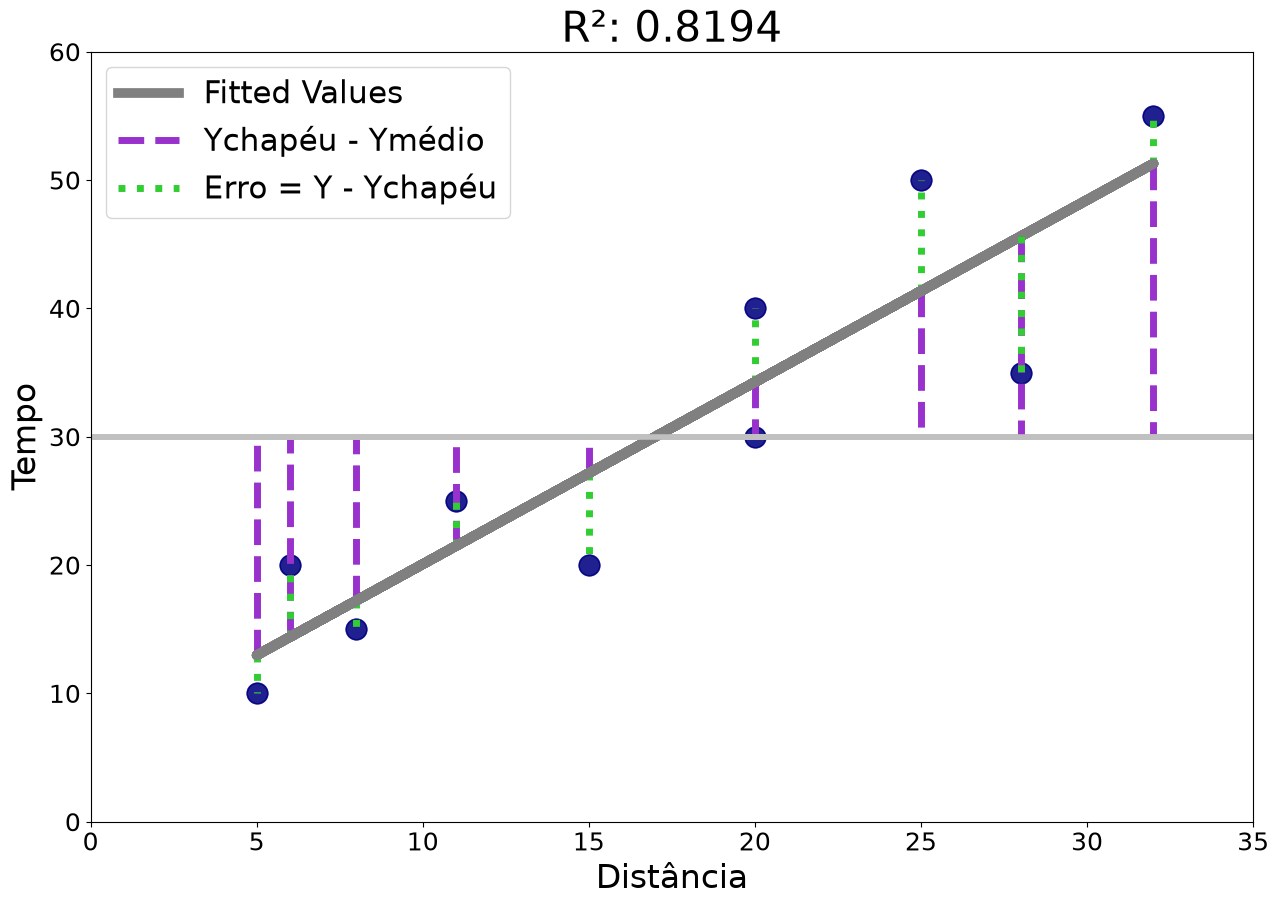

In [11]:
plt.figure(figsize=(15,10))
y = df_tempodist['tempo']
yhat = df_tempodist['yhat']
x = df_tempodist['distancia']
mean = np.full(x.shape[0] , y.mean(), dtype=int)

for i in range(len(x)-1):
    plt.plot(x, yhat, color='grey', linewidth=7)
    plt.plot([x[i], x[i]], [yhat[i], mean[i]], '--', color='darkorchid',
             linewidth=5)
    plt.plot([x[i], x[i]], [yhat[i], y[i]],':', color='limegreen', linewidth=5)
    plt.scatter(x, y, color='navy', s=220, alpha=0.2)
    plt.axhline(y = y.mean(), color = 'silver', linestyle = '-', linewidth=4)
    plt.title('R²: ' + str(round(modelo.rsquared, 4)), fontsize=30)
    plt.xlabel('Distância', fontsize=24)
    plt.ylabel('Tempo', fontsize=24)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlim(0, 35)
    plt.ylim(0, 60)
    plt.legend(['Fitted Values', 'Ychapéu - Ymédio', 'Erro = Y - Ychapéu'],
               fontsize=22, loc='upper left')
plt.show()

#### Cálculo manual do R²

In [12]:
R2 = ((df_tempodist['yhat']-
       df_tempodist['tempo'].mean())**2).sum()/(((df_tempodist['yhat']-
                                        df_tempodist['tempo'].mean())**2).sum()+
                                        (df_tempodist['erro']**2).sum())

float(round(R2,4))

0.8194

#### Coeficiente de ajuste (R²) é a correlação ao quadrado

In [13]:
# Correlação de Pearson
df_tempodist[['tempo','distancia']].corr()

,tempo,distancia
tempo,1.000000,0.905221
distancia,0.905221,1.000000


In [14]:
# R²
(df_tempodist[['tempo','distancia']].corr())**2

,tempo,distancia
tempo,1.000000,0.819426
distancia,0.819426,1.000000


In [15]:
# R² de maneira direta
float(modelo.rsquared)

0.8194256756756757

# Resumo: Regressão Linear Simples
Este documento apresenta um resumo do fluxo de código do notebook `06_1_regressao_linear_simples.ipynb`, focado na análise da relação entre **Distância** e **Tempo**.

---

## 1. Preparação e Exploração
- **Objetivo:** Entender como a "Distância" (causa/X) influencia o "Tempo" (resultado/Y).
- **Dados:** O arquivo `tempodist.csv` é carregado, contendo 10 observações.
- **Análise Inicial:** Uso de `describe()` para estatísticas descritivas (média, desvio padrão, etc) e `info()` para verificar tipos de dados.

## 2. Visualização Inicial
- É gerado um gráfico de dispersão com uma linha de tendência usando `seaborn.regplot`.
- Isso permite visualizar rapidamente se os pontos seguem uma tendência linear (se o tempo aumenta proporcionalmente à distância).

## 3. Construção do Modelo (O Coração do Código)
O modelo de **Mínimos Quadrados Ordinários (OLS)** é estimado:
```python
modelo = sm.OLS.from_formula('tempo ~ distancia', df_tempodist).fit()
```
- A fórmula `'tempo ~ distancia'` indica que o Tempo depende da Distância.
- O `fit()` faz o computador encontrar os melhores números para a reta.

## 4. Interpretação dos Resultados
Ao rodar `modelo.summary()`, obtemos:
- **R-squared (0.819):** Indica que o modelo explica **81,9%** da variação dos dados. É um ajuste muito bom.
- **Coeficientes:**
    - **Intercepto (5.8784):** O tempo estimado quando a distância é zero.
    - **Distância (1.4189):** Para cada 1 unidade de distância a mais, o tempo aumenta em média 1.42 unidades.
- **P-value (distancia < 0.001):** Como é menor que 0.05, a distância é estatisticamente significante para prever o tempo.

**Na ciência, nós definimos uma "linha de corte" chamada Nível de Significância ($\alpha$). O padrão é 0,05 (5%).**

    - **P-value > 0,05:** "Pode ser sorte, não confio." (Não rejeitamos a hipótese de que é coincidência).

    - **P-value < 0,05:** "É impossível ser sorte!" (Rejeitamos a ideia de coincidência).

## 5. Previsões e Erros
O código salva os resultados individuais no DataFrame:
- **yhat (`fittedvalues`):** O valor que o modelo previu para cada distância.
- **erro (`resid`):** A diferença entre o que aconteceu de verdade e o que o modelo previu ($Real - Previsto$).

## 6. Diagnóstico dos Resíduos
Para garantir que o modelo é confiável, são feitos testes nos erros:
- **Normalidade (Shapiro-Francia/Jarque-Bera):** Verifica se os erros seguem uma distribuição normal.
- **Autocorrelação (Durbin-Watson):** Um valor próximo de 2 (como o 2.099 encontrado) indica que os erros são independentes, o que é ideal.

---
**Conclusão do Notebook:** Existe uma relação linear forte e positiva entre distância e tempo, permitindo fazer previsões confiáveis com o modelo gerado.
